In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import random
# 生成图像和对应标签
df=pd.read_csv('data/data106996/age_gender.csv')

! rm -r -f img
! rm -r -f train
print("正在读取数据集")
def pixels2image(pixels): 
    return np.array(pixels.split()).astype(np.float).reshape(48, 48)

imagesdatalist = []
imageslabellist = []
valimagesdatalist = []
valimageslabellist = []
for i in range(len(df)):
    pixels=df['pixels'][i]
    img = pixels2image(pixels)
    gender = df['gender'][i]
    age = df['age'][i]
    if age<100:
        al =age//5
    # elif age<=90:
    #     al = 16
    # elif age <= 100:
    #     al = 17
    else:
        al = 20
    cla = (al)*2 + gender
    if random.randint(0, 10) == 1:
        valimagesdatalist.append(img)
        valimageslabellist.append(cla)
    else:
        imagesdatalist.append(img)
        imageslabellist.append(cla)
    # img=Image.fromarray(img)
    # img.convert('L').save("train/"+str(cla)+"s"+str(i)+'.jpg')


正在读取数据集


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/ipykernel_launcher.py:12: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if sys.path[0] == '':


In [2]:
# 生成paddle数据集
%cd /home/aistudio

import os
import cv2
import numpy as np
from paddle.io import Dataset
# 生成label
from matplotlib import pyplot as plt

class MyDataset(Dataset):
    """
    步骤一：继承 paddle.io.Dataset 类
    """
    def __init__(self, datalist,labellist, transform=None):
        """
        步骤二：实现 __init__ 函数，初始化数据集，将样本和标签映射到列表中
        """
        super(MyDataset, self).__init__()
        self.data_list = []
        for i,image in enumerate(datalist):
            # print(image.shape)
            image = np.array([image]).astype('uint8')
            image = np.transpose(image, (1,2,0))
            # image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
            # 调整到可以进入该模型输入的大小
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            label=labellist[i]
            # image = cv2.resize(image, (48, 48))
            self.data_list.append([image, label])
        print(len(self.data_list))
        random.shuffle(self.data_list)
        # 传入定义好的数据处理方法，作为自定义数据集类的一个属性
        self.transform = transform

    def __getitem__(self, index):
        """
        步骤三：实现 __getitem__ 函数，定义指定 index 时如何获取数据，并返回单条数据（样本数据、对应的标签）
        """
        # 根据索引，从列表中取出一个图像
        image, label = self.data_list[index]        

        # 将图片尺寸缩放道 224x224
        
        # 读入的图像数据格式是[H, W, C]
        # 使用转置操作将其变成[C, H, W]
        

        # # image = cv2.imread(image_path)
        if self.transform is not None:
            image = self.transform(image)
        # # 飞桨训练时内部数据格式默认为float32，将图像数据格式转换为 float32
        # image = image.astype('float32')
        # image = image.transpose(2, 0, 1)
        # # 应用数据处理方法到图像上
        
        image = np.transpose(image, (2,0,1))
        image = image.astype('float32')
        # 将数据范围调整到[-1.0, 1.0]之间
        image = image / 255.
        image = image * 2.0 - 1.0

        # CrossEntropyLoss要求label格式为int，将Label格式转换为 int
        label = int(label)
        # 返回图像和对应标签
        return image, label
    def show_image(self,id):
        image = self.data_list[id][0]
        plt.imshow(image)
    def set_len(self,lenth):
        self.data_list = self.data_list[:lenth]
    def __len__(self):
        """
        步骤四：实现 __len__ 函数，返回数据集的样本总数
        """
        return len(self.data_list)
print("preparing datasets")
from paddle.vision.transforms import Compose, RandomRotation,Resize,Normalize,RandomHorizontalFlip,ColorJitter
transform = Compose([ColorJitter(0.6, 0.5, 0.5, 0.4),RandomRotation(30),RandomHorizontalFlip(0.5)])
# transform = Normalize(mean=[127.5], std=[127.5], data_format='CHW')
print(len(imageslabellist),len(valimageslabellist),len(set(imageslabellist)),len(set(valimageslabellist)))
num =len(imagesdatalist)
# 打印数据集样本数        
train_dataset = MyDataset(imagesdatalist,imageslabellist,transform)
val_dataset = MyDataset(valimagesdatalist,valimageslabellist,transform)
train_dataset.show_image(0)
# val_dataset.show_image(0)
print('train_custom_dataset images: ',len(train_dataset), 'test_custom_dataset images: ',len(val_dataset))

/home/aistudio


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/__init__.py:107: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import MutableMapping
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/rcsetup.py:20: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import Iterable, Mapping
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/colors.py:53: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import Sized


preparing datasets
21483 2222 41 41
21483
2222
train_custom_dataset images:  21483 test_custom_dataset images:  2222


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:2349: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  if isinstance(obj, collections.Iterator):
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:2366: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  return list(data) if isinstance(data, collections.MappingView) else data


In [3]:
import paddle
from paddle.vision.models import MobileNetV2,mobilenet_v2

print('飞桨框架内置模型：', paddle.vision.models.__all__)
network =paddle.vision.models.mobilenet_v2(pretrained=True,num_classes=42)
model = paddle.Model(network)
#训练
# 指定在 CPU 上训练
paddle.device.set_device('cpu')

# 指定在 GPU 第 0 号卡上训练
# paddle.device.set_device('gpu:0')
# 重新加载模型
params_file_path = '/home/aistudio/checkpoint/mobilenet_v2'
model.load(params_file_path)
model.prepare(paddle.optimizer.Adam(learning_rate=0.001,parameters=model.parameters()),
              paddle.nn.CrossEntropyLoss(),
              paddle.metric.Accuracy())


飞桨框架内置模型： ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'VGG', 'vgg11', 'vgg13', 'vgg16', 'vgg19', 'MobileNetV1', 'mobilenet_v1', 'MobileNetV2', 'mobilenet_v2', 'LeNet']


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/dygraph/layers.py:1441: UserWarning: Skip loading for classifier.1.weight. classifier.1.weight receives a shape [1280, 1000], but the expected shape is [1280, 42].
  warnings.warn(("Skip loading for {}. ".format(key) + str(err)))
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/dygraph/layers.py:1441: UserWarning: Skip loading for classifier.1.bias. classifier.1.bias receives a shape [1000], but the expected shape is [42].
  warnings.warn(("Skip loading for {}. ".format(key) + str(err)))


## 预测与导出


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/layers/utils.py:77: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  return (isinstance(seq, collections.Sequence) and


Predict begin...
step 100/100 [==============================] - 29ms/step          
Predict samples: 100
35-40 False
45-50 True
15-20 False
15-20 False
60-65 False
5-10 True
25-30 True
25-30 True
0-5 False
0-5 False
15-20 False
15-20 False
55-60 True
55-60 True
25-30 False
25-30 False
60-65 True
60-65 True
50-55 False
50-55 False
15-20 False
15-20 False
25-30 False
25-30 False
65-70 False
65-70 False
35-40 True
35-40 True
35-40 False
35-40 False
5-10 False
5-10 False
0-5 True
0-5 True
30-35 False
25-30 False
75-80 True
75-80 True
45-50 True
45-50 True
30-35 False
30-35 False
5-10 True
5-10 True
25-30 False
25-30 False
25-30 False
45-50 True
30-35 True
30-35 True
35-40 True
35-40 True
60-65 True
60-65 True
0-5 False
0-5 False
35-40 False
35-40 False
5-10 False
5-10 False
35-40 True
35-40 True
30-35 True
30-35 True
25-30 False
25-30 False
40-45 True
40-45 True
30-35 False
30-35 False
35-40 False
35-40 False
25-30 True
25-30 True
25-30 True
25-30 True
45-50 True
45-50 True
50-55 True
50-

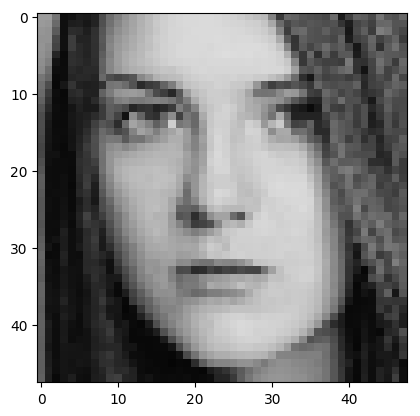

In [4]:
# 加载测试数据集
test_loader = paddle.io.DataLoader(val_dataset, batch_size=1, drop_last=True)
# 将该模型及其所有子层设置为预测模式
def get_gender_age(idlabel):
    age = str((idlabel//2)*5)+"-"+str((idlabel//2+1)*5)
    gender = idlabel%2 == 0
    print(age,gender)
    return age,gender
val_dataset.set_len(100)
test_result = model.predict(test_loader,verbose=1)
pred_labels = []
true_num=0
for i,data in enumerate(val_dataset):
    img, label = data
    # 打印推理结果，这里的argmax函数用于取出预测值中概率最高的一个的下标，作为预测标签
    pred_label = test_result[0][i].argmax()
    pred_labels.append(str(get_gender_age(pred_label))+"|"+str(get_gender_age(label)))
    # print('{} true label: {}, pred label: {} {}'.format(val_dataset.data_list[i],result_dict[label], result_dict[pred_label],label==pred_label))
    if label == pred_label:
        true_num+=1
print(true_num/len(val_dataset))
val_dataset.show_image(1)
import numpy as np
print(np.array(pred_labels[:20]).reshape(4,5))



In [5]:
!pip install paddle2onnx
!pip install onnx==1.8.0

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 2.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.1.2 -> 22.3.1
[notice] To update, run: pip install --upgrade pip
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 1.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.1.2 -> 22.3.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import os
import time
import paddle


# 将模型设置为评估状态
# result = model.evaluate(val_dataset, verbose=1,batch_size=10)
# print(result)
# 定义输入数据
input_spec = paddle.static.InputSpec(shape=[1,3, 48, 48], dtype='float32', name='image')

# ONNX模型导出
paddle.onnx.export(network,"output/mobilenet_v2", input_spec=[input_spec], opset_version=10)


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/dygraph/dygraph_to_static/convert_call_func.py:93: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  func_in_dict = func == v


2022-12-02 17:07:44 [INFO]	Static PaddlePaddle model saved in output/paddle_model_static_onnx_temp_dir.
[Paddle2ONNX] Start to parse PaddlePaddle model...
[Paddle2ONNX] Model file path: output/paddle_model_static_onnx_temp_dir/model.pdmodel
[Paddle2ONNX] Paramters file path: output/paddle_model_static_onnx_temp_dir/model.pdiparams
[Paddle2ONNX] Start to parsing Paddle model...
[Paddle2ONNX] Use opset_version = 10 for ONNX export.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2022-12-02 17:07:44 [INFO]	ONNX model saved in output/mobilenet_v2.onnx.


In [7]:
# 更改 ONNX 库版本,让低版本也可以用
import onnx
# 载入 ONNX 模型
onnx_model = onnx.load("output/mobilenet_v2.onnx")
# 使用 ONNX 库检查 ONNX 模型是否合理
# check = onnx.checker.check_model(onnx_model)
# # 打印检查结果
# print('check: ', check)
# onnx_model.graph.input[0].type.tensor_type.shape.dim[0].dim_param = '?'
onnx_model.ir_version = 6
onnx.save_model(onnx_model, "output/mobilenet_v2_onnx6.onnx")
# onnx.save(onnx_model, 'output/testModelOutput.onnx')

/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/onnx/mapping.py:25: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  int(TensorProto.STRING): np.dtype(np.object)


In [8]:
# import os
# import time
# import paddle

# from paddle.vision.models import MobileNetV2,mobilenet_v2
# model = mobilenet_v2(pretrained=False,num_classes=7)
# # 加载预训练模型参数
# model.set_dict(paddle.load('checkpoint/mobilenet_v2.pdparams'))

# # 将模型设置为评估状态
# model.eval()

# # 定义输入数据
# input_spec = paddle.static.InputSpec(shape=[None, 3, 48, 48], dtype='float32', name='image')

# # ONNX模型导出
# paddle.onnx.export(model, 'output/test', input_spec=[input_spec], opset_version=10)


In [9]:
!pip install onnx

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip available: 22.1.2 -> 22.3.1
[notice] To update, run: pip install --upgrade pip


In [10]:
# 使用onnxruntime
!pip install onnxruntime


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 1.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.6/532.6 kB 1.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.1.2 -> 22.3.1
[notice] To update, run: pip install --upgrade pip


In [11]:
# 动态图导出的ONNX模型测试
import time
import numpy as np
import cv2
from onnxruntime import InferenceSession

# result_dict = {0:"SA",1:"DI",2:"HA",3:"FE",4:"SU",5:"NE",6:"AN"}
# name =[result_dict[i] for i in range(7)]
# #直接加载图片
# data_dir="upload_image"
# filenames = os.listdir(data_dir)
# for name in filenames:
#     image_path = os.path.join(data_dir, name)
#     image = cv2.imread(image_path)
#     face_locations = face_recognition.face_locations(image)
#     image= cv2.resize(image,(48,48))
#     image = image.astype('float32')
#     image = image.transpose(2, 0, 1)
#     print(image.shape)
#     start = time.time()
#     d0 = model.run(output_names=None, input_feed={'image': x})
#     pred_label = np.array(d0[0][0]).argmax()
#     print(pred_label,label,pred_label==label)
#     if pred_label==label:
#         true_num+=1
#     end = time.time()
#     print('predict time: %.04f s' % (end - start))
# 用测试集使用ONNX模型
model_InferenceSession = InferenceSession('output/mobilenet_v2.onnx')
true_num = 0
for image,label in val_dataset:
    x = np.array([image])
    # 准备输入
    # x = np.random.random((1, 3, 48, 48)).astype('float32')
    # 速度测试
    start = time.time()
    d0 = model_InferenceSession.run(output_names=None, input_feed={'image': x})
    pred_label = np.array(d0[0][0]).argmax()
    print(pred_label,label,pred_label==label)
    if pred_label==label:
        true_num+=1
    end = time.time()
    print('predict time: %.04f s' % (end - start))
print(true_num/len(val_dataset))

18 18 True
predict time: 0.0607 s
11 7 False
predict time: 0.1008 s
2 2 True
predict time: 0.0021 s
10 10 True
predict time: 0.0028 s
1 1 True
predict time: 0.0027 s
11 7 False
predict time: 0.0028 s
22 22 True
predict time: 0.0914 s
11 11 True
predict time: 0.0961 s
24 24 True
predict time: 0.1010 s
21 21 True
predict time: 0.0975 s
7 7 True
predict time: 0.0964 s
11 11 True
predict time: 0.0023 s
35 27 False
predict time: 0.1010 s
10 14 False
predict time: 0.0023 s
15 15 True
predict time: 0.1006 s
3 3 True
predict time: 0.0960 s
0 0 True
predict time: 0.0964 s
11 11 True
predict time: 0.1989 s
30 30 True
predict time: 0.1014 s
18 18 True
predict time: 0.0021 s
13 13 True
predict time: 0.0998 s
2 2 True
predict time: 0.0036 s
11 11 True
predict time: 0.0958 s
11 18 False
predict time: 0.0037 s
12 12 True
predict time: 0.1015 s
14 14 True
predict time: 0.0957 s
24 24 True
predict time: 0.1002 s
1 1 True
predict time: 0.0955 s
15 15 True
predict time: 0.1001 s
3 3 True
predict time: 0.

In [12]:
# opencv 推理
# import cv2
# net = cv2.dnn.readNetFromONNX("output/dynamic_model.onnx")  # 加载训练好的识别模型
# image = cv2.imread("test/SU00227.jpg")  # 读取图片
# blob = cv2.dnn.blobFromImage(image,size=(48,48))  # 由图片加载数据 这里还可以进行缩放、归一化等预处理
# print(blob)
# net.setInput(blob)  # 设置模型输入
# out = net.forward()  # 推理出结果


error: OpenCV(4.6.0) /io/opencv/modules/dnn/src/onnx/onnx_importer.cpp:255: error: (-5:Bad argument) Can't read ONNX file: output/dynamic_model.onnx in function 'ONNXImporter'
